In [1]:
import copy
import pickle
import inspect
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
from rich import progress
from scipy import constants

from rich.progress import (
    Progress,
    BarColumn,
    TextColumn,
    TransferSpeedColumn,
    TimeRemainingColumn,
)
plt.rcParams.update({"font.size": 10})
class TaskSpeed(progress.ProgressColumn):
    def render(self, task):
        if task.speed is None:
            return ""
        elif task.speed >= 0.1:
            return f"{(task.speed or 0):.1f}/s"
        else:
            return f"{(1 / task.speed or 0):.1f} s/i"

# --- Define the file wrapper ---
class RichProgressFileWrapper:
    def __init__(self, file_obj, progress, task_id):
        self.file_obj = file_obj
        self.progress = progress
        self.task_id = task_id

    def read(self, size=-1):
        """Read bytes and update the progress bar."""
        chunk = self.file_obj.read(size)
        self.progress.update(self.task_id, advance=len(chunk))
        return chunk

    def __getattr__(self, name):
        """Delegate other attribute access to the original file object."""
        return getattr(self.file_obj, name)

## Calculate DET chamber vx distributions

In [2]:
# Syntax: %run filename.py --arg_name value
!python read_analyze_files.py --root "saved_trajectories_vz_184ms_mean" --aperture_xs 20e-3 --aperture_ys 10e-3

XS Array: [0.02] | Type: <class 'numpy.ndarray'>
YS Array: [0.01] | Type: <class 'numpy.ndarray'>
YS Offset Array: [0.] | Type: <class 'numpy.ndarray'>
Current root is: saved_trajectories_vz_184ms_mean
Starting parallel processing of 12 files on 32 cores...

Overall Progress -----------------------------   0% •  0/12 • 0:00:00 | -:--:--
Overall Progress -----------------------------   0% •  0/12 • 0:00:00 | -:--:--
Overall Progress -----------------------------   0% •  0/12 • 0:00:00 | -:--:--
Overall Progress -----------------   0% •  0/12             • 0:00:00 | -:--:--
 Loading 0.0.pkl -----------------   0% •        0/29212398 • 0:00:00 | -:--:--
   Overall Progress ---------------   0% •  0/12            • 0:00:00 | -:--:--
    Loading 0.0.pkl ---------------   0% •        0/292123… • 0:00:00 | -:--:--
Loading 10000.0.pkl ---------------   0% •       0/8262846  • 0:00:00 | -:--:--
   Overall Progress ---------------   0% •  0/12            • 0:00:00 | -:--:--
    Loading 0.0.pkl -

## Import DET chamber vx distributions

In [3]:
with open("final_vs_distribution.pkl", "rb") as f:
    final_vs_distribution = pickle.load(f)


In [4]:
counts_vs_vx = {}
bin_edges = np.linspace(-2, 2, 41)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

In [5]:

for k1, data1 in final_vs_distribution.items(): # k1 is mF=0
    for k2, data2 in data1.items(): # k2 is distribution type
        for k3, data3 in data2.items(): # k3 is distribution parameter
            for k4, data4 in data3.items(): # k4 is voltage
                for aperture_size_x, data5 in data4.items():
                    for aperture_size_y, data6 in data5.items():
                        for aperture_offset_y, v in data6.items():
                            h, _ = np.histogram(v, bins=bin_edges)
                            counts_vs_vx.setdefault(k1, {})\
                                .setdefault(k2, {})\
                                .setdefault(k3, {})\
                                .setdefault(k4, {})\
                                .setdefault(aperture_size_x, {})\
                                .setdefault(aperture_size_y, {})\
                                .setdefault(aperture_offset_y, h)

#### Plot Gain vs Detuning (using simulation to convolve)

In [6]:
try:
    from centrex_tlf import utils
    _DET = utils.detuning.velocity_to_detuning(1)
except ImportError:
    _DET = 23054294.945029873

import numpy as np
v_to_Γ = _DET / (2 * np.pi * 1e6 * 4)  # Convert velocity to detuning in GHz
v_to_Γ


0.9173012500000001

In [7]:
# raise KeyboardInterrupt
with open("counts_vs_vx.pkl", "wb") as f:
    pickle.dump(counts_vs_vx, f, protocol=pickle.HIGHEST_PROTOCOL)

## Run OBE convolve with expanded beam

In [8]:
!python signal_vs_detuning.py

Preparing tasks for parallel execution...
Starting processing of 12 tasks on multiple cores...

Calculating signal ----------------------------------------------  0/12 -:--:--
Calculating signal ----------------------------------------------  0/12 -:--:--
Calculating signal ----------------------------------------------  0/12 -:--:--
Calculating signal ---------------------------------------------- 12/12 0:00:00
Calculating signal ---------------------------------------------- 12/12 0:00:00

Processing complete. Saving results...
Done.


## Read 

In [9]:
import os
with progress.Progress(
        progress.TextColumn("[progress.description]{task.description}"),
        progress.BarColumn(bar_width=None),
        progress.TaskProgressColumn(),
        progress.MofNCompleteColumn(),
        progress.TimeElapsedColumn(),
        progress.TimeRemainingColumn(),
) as pb:
    fname = "signal_vs_detuning_broadened.pkl"
    with open(fname, "rb") as f:
        wrapped_f = RichProgressFileWrapper(f, pb, pb.add_task("Loading signal_vs_detuning.pkl", total=os.path.getsize(fname)))
        signal_vs_detuning = pickle.load(wrapped_f)

Output()

In [10]:
with open("results_vertical_expanded_beam.pkl", "rb") as f:
    results_scan_expanded_beam = pickle.load(f)

# Assuming bin_centers and v_to_Γ are defined somewhere
# Example placeholder values:
bin_edges = np.linspace(-2, 2, 41)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
v_to_Γ = 0.9173012617949181


res = results_scan_expanded_beam[0.5]
df = np.diff(bin_centers*v_to_Γ)[0]
freqs = np.arange(res[0].min()-df, res[0].max()-df, df)


In [11]:
from uncertainties import ufloat
signal_data_0kV_experiment = {
    22.5: {
        2156.25: ufloat(0.00772, 0.0018),
        2156.75: ufloat(0.0105, 0.002),
        2157.25: ufloat(0.0147, 0.0012),
        2157.75: ufloat(0.0284, 0.0012),
        2158.25: ufloat(0.0883, 0.0057),
        2158.75: ufloat(0.136, 0.0056),
        2159.25: ufloat(0.0874, 0.0054),
        2159.75: ufloat(0.0318, 0.0019),
        2160.25: ufloat(0.0131, 0.0019),
        2160.75: ufloat(0.00901, 0.0018),
        2161.25: ufloat(0.00656, 0.0022)
    },
    26.25: {
        2156.25: ufloat(0.00952, 0.001),
        2156.75: ufloat(0.0148, 0.0026),
        2157.25: ufloat(0.0157, 0.0019),
        2157.75: ufloat(0.0312, 0.0026),
        2158.25: ufloat(0.0837, 0.0049),
        2158.75: ufloat(0.142, 0.0036),
        2159.25: ufloat(0.083, 0.0025),
        2159.75: ufloat(0.0315, 0.0013),
        2160.25: ufloat(0.0141, 0.0014),
        2160.75: ufloat(0.0082, 0.0026),
        2161.25: ufloat(0.00767, 0.0017)
    },
 30.0: {
        2156.25: ufloat(0.00628, 0.00072),
        2156.75: ufloat(0.00698, 0.00075),
        2157.25: ufloat(0.0142, 0.00083),
        2157.75: ufloat(0.0296, 0.0011),
        2158.25: ufloat(0.0801, 0.0036),
        2158.75: ufloat(0.123, 0.0047),
        2159.25: ufloat(0.0886, 0.0026),
        2159.75: ufloat(0.035, 0.0039),
        2160.25: ufloat(0.0129, 0.0019),
        2160.75: ufloat(0.00753, 0.001),
        2161.25: ufloat(0.00691, 0.001)
    }
}

signal_vs_frequency_0_kV = {

}

signal_vs_frequency_0_kV = {

}

signal_data_experiment = {
    0.0: {
        2161.0: ufloat(0.000291, 0.00015),
        2161.5: ufloat(0.000381, 9.1e-05),
        2162.0: ufloat(0.000833, 0.00012),
        2162.5: ufloat(0.00151, 0.00013),
        2163.0: ufloat(0.0027, 0.0001),
        2163.5: ufloat(0.00225, 0.00021),
        2164.0: ufloat(0.0011, 0.0002),
        2164.5: ufloat(0.000545, 0.0001),
        2165.0: ufloat(0.000152, 0.00012)
    },
    20.0: {
        2161.0: ufloat(0.000977, 8.9e-05),
        2161.5: ufloat(0.00243, 9.6e-05),
        2162.0: ufloat(0.00461, 0.00037),
        2162.5: ufloat(0.0117, 0.0006),
        2163.0: ufloat(0.02, 0.00096),
        2163.5: ufloat(0.017, 0.00068),
        2164.0: ufloat(0.00883, 0.00039),
        2164.5: ufloat(0.00392, 0.0002),
        2165.0: ufloat(0.00172, 0.00013)
    },
    22.5: {
        2161.0: ufloat(0.00179, 0.00016),
        2161.5: ufloat(0.00394, 0.00025),
        2162.0: ufloat(0.009, 0.00032),
        2162.5: ufloat(0.0185, 0.00076),
        2163.0: ufloat(0.03, 0.0013),
        2163.5: ufloat(0.0257, 0.0015),
        2164.0: ufloat(0.0158, 0.00078),
        2164.5: ufloat(0.00629, 0.00027),
        2165.0: ufloat(0.003, 0.00019)
    },
    26.25: {
        2161.0: ufloat(0.00245, 0.00016),
        2161.5: ufloat(0.00512, 0.00018),
        2162.0: ufloat(0.011, 0.00036),
        2162.5: ufloat(0.0225, 0.0004),
        2163.0: ufloat(0.0316, 0.00066),
        2163.5: ufloat(0.0316, 0.00069),
        2164.0: ufloat(0.019, 0.00033),
        2164.5: ufloat(0.00806, 0.00012),
        2165.0: ufloat(0.00374, 0.00012)
    },
    30.0: {
        2161.0: ufloat(0.00219, 0.00017),
        2161.5: ufloat(0.00402, 0.00018),
        2162.0: ufloat(0.00882, 0.00022),
        2162.5: ufloat(0.0161, 0.00024),
        2163.0: ufloat(0.0204, 0.0007),
        2163.5: ufloat(0.0209, 0.00042),
        2164.0: ufloat(0.015, 0.00056),
        2164.5: ufloat(0.00695, 0.0003),
        2165.0: ufloat(0.00314, 0.00016)
    }
}

freq_offset_experiment = 2163

In [104]:
import numpy as np
gains = []
for hv_voltage in signal_data_experiment.keys():
    heights = np.array(list(signal_data_experiment[hv_voltage].keys()))
    mask = np.array(abs(freq_offset_experiment-heights)) < 1.5
    signals = np.array(list(signal_data_experiment[hv_voltage].values()))[mask]
    # print(f"HV {hv_voltage} V: {[f'{s.n*scale_exp:.2f}' for s in signals]}")
    gains.append(np.trapezoid(signals))
gains = np.array([g/gains[0] for g in gains])
print([round(g.n, 2) for g in gains])
print([round(g.s, 2) for g in gains])

[1.0, 7.49, 11.84, 13.85, 9.73]
[0.0, 0.35, 0.56, 0.59, 0.42]


In [105]:
signals

array([0.00882+/-0.00022, 0.0161+/-0.00024, 0.0204+/-0.0007,
       0.0209+/-0.00042, 0.015+/-0.00056, 0.00695+/-0.0003], dtype=object)

In [37]:
np.array(list(signal_data_experiment[30].keys()))-2163

array([-2. , -1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,  2. ])

In [101]:
import numpy as np
gains = []
signal_0kV = None
for hv_voltage, data3 in signal_vs_detuning['mF=0'][0.02][0.01].items():
    if float(hv_voltage) / 1000 not in signal_data_experiment.keys():
        continue
    mask = np.isclose(abs(freqs)[:, None], [0, 0.5, 1], atol=5e-2).any(axis=-1)
    signals = np.array(data3['gaussian']['0.0022'][0])[mask]
    # print(f"HV {hv_voltage} V: {[f'{s.n*scale:.2f}' for s in signals]}")
    gains.append(np.mean(signals))
    
gains = np.array([g/gains[0] for g in gains])
print([round(g.n, 2) for g in gains])
print([round(g.s, 2) for g in gains])

[1.0, 7.02, 12.39, 16.09, 11.59]
[0.0, 0.24, 0.41, 0.53, 0.39]


In [31]:
scale_exp = 1/np.max([v.n for v in signal_data_experiment[0].values()])
try:
    scale = 1/np.max([g.n for g in signal_vs_detuning['mF=0'][0.0254][0.003]['0.0']['gaussian']['0.0022'][0]])
except KeyError:
    try:
        scale = 1/np.max([g.n for g in signal_vs_detuning['mF=0'][0.025][0.003]['0.0']['gaussian']['0.0022'][0]])
    except KeyError:
        scale = 1/np.max([g.n for g in signal_vs_detuning['mF=0'][0.02][0.01]['0.0']['gaussian']['0.0022'][0]])

Voltage: 0.0, Scale: 2.0727792893714316e-07, Max sim: 4824440.330563362, Max exp: 0.0027
Voltage: 20000.0, Scale: 2.0727792893714316e-07, Max sim: 31741765.829579845, Max exp: 0.02
Voltage: 22500.0, Scale: 2.0727792893714316e-07, Max sim: 52716315.7945686, Max exp: 0.03
Voltage: 26250.0, Scale: 2.0727792893714316e-07, Max sim: 61681020.220230475, Max exp: 0.0316
Voltage: 30000.0, Scale: 2.0727792893714316e-07, Max sim: 41657672.907983035, Max exp: 0.0209


Text(0.5, 0.98, 'vz mean=184 m/s simulation')

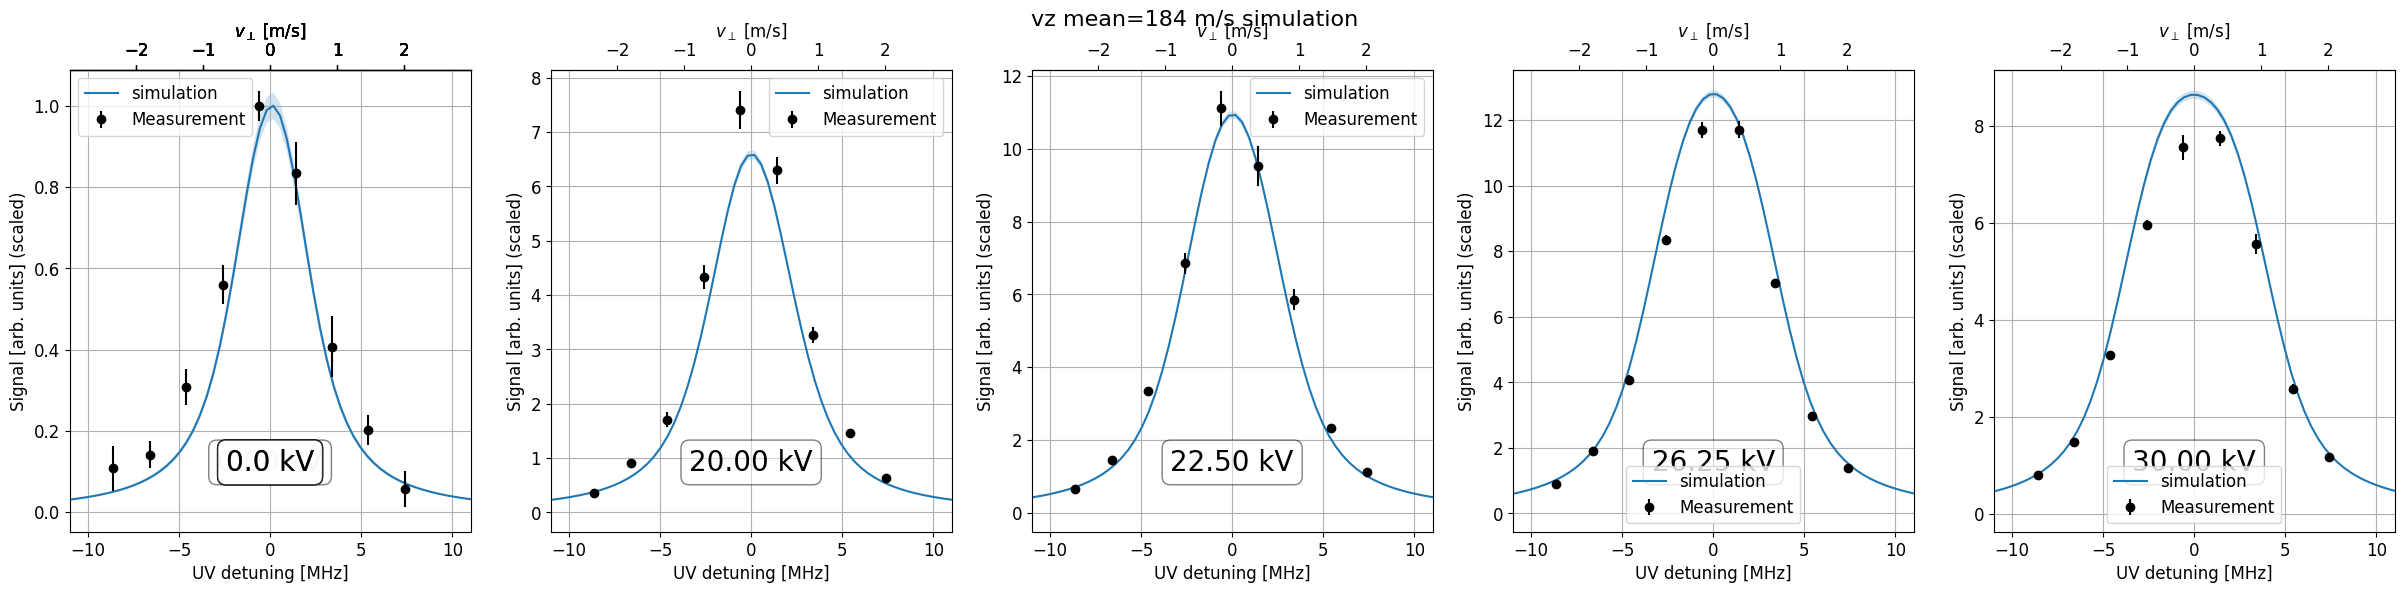

In [100]:

fig, axs = plt.subplots(1, 5, figsize=(30, 6), sharey=False)
velocity_to_detuning = 23054295.241468497 / (2 * np.pi * 1e6)
plt.rcParams.update({'font.size': 12})
from scipy.optimize import minimize
i = -1
j = 0
freq_offset_experiment = 2163.15
for aperture_size_x, data1 in signal_vs_detuning['mF=0'].items():
    for aperture_size_y, data2 in data1.items():
        for voltage, data3 in data2.items():
            if float(voltage) / 1000 not in signal_data_experiment.keys():
                continue
            # if not (np.isclose(aperture_size_x, 0.02) and np.isclose(aperture_size_y, 0.005)) and True:
            #     continue
            i += 1
            ax2 = axs[i]
            ax1 = axs[0]
            secax2 = ax2.secondary_xaxis('top', functions=(lambda x: x / velocity_to_detuning, lambda x: x * velocity_to_detuning))
            secax1 = ax1.secondary_xaxis('top', functions=(lambda x: x / velocity_to_detuning, lambda x: x * velocity_to_detuning))
            secax1.set_xlabel(r"$v_\perp$ [m/s]")
            secax2.set_xlabel(r"$v_\perp$ [m/s]")
            signal_vs_freq = None
            for param, data4 in data3['gaussian'].items():
                data4 = data4[0]
                mask = np.array([g.n for g in data4]) > 0
                ax2.fill_between(
                    4 * freqs[mask],
                    (np.array([g.n for g in data4]) + np.array([g.s for g in data4]))[mask] * scale,
                    (np.array([g.n for g in data4]) - np.array([g.s for g in data4]))[mask] * scale,
                    alpha=0.2,
                )
                data4_0kV = data2['0.0']['gaussian'][param][0]
                mask = np.array([g.n for g in data4_0kV]) > 0
                # if j == 0:
                    # ax1.fill_between(
                    #     4 * freqs[mask],
                    #     (np.array([g.n for g in data4_0kV]) + np.array([g.s for g in data4_0kV]))[mask] * scale,
                    #     (np.array([g.n for g in data4_0kV]) - np.array([g.s for g in data4_0kV]))[mask] * scale,
                    #     alpha=0.2,
                    # )
                    # ax1.plot(
                    #     4 * freqs[mask],
                    #     np.array([g.n for g in data4_0kV])[mask] * scale,
                    #     label="simulation",
                    # )
                line = ax2.plot(
                    4 * freqs[mask],
                    np.array([g.n for g in data4])[mask] * scale,
                    label="simulation",
                )
                # if float(voltage) == 0:
                #     continue
                
                experiment_data = signal_data_experiment[float(voltage) / 1000]
                ax_to_plot = ax1 if float(voltage) == 0 else ax2
                if float(voltage) == 0 or True:
                    print(f"Voltage: {voltage}, Scale: {scale}, Max sim: {np.max(np.array([g.n for g in data4]))}, Max exp: {np.max([v.n for v in experiment_data.values()])}")
                ax_to_plot.errorbar(
                    4 * (np.fromiter(experiment_data.keys(), dtype=np.float64) - freq_offset_experiment),
                    [v.n*scale_exp for v in experiment_data.values()],
                    yerr=[v.s*scale_exp for v in experiment_data.values()],
                    color='k',
                    fmt="o",
                    label=f"Measurement",
                )
            j += 1
            ax2.text(
                0.5, 0.15, f"{float(voltage) / 1000:.2f} kV",
                transform=ax2.transAxes,
                fontsize=20,
                ha='center',
                va='center',
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
            )
            ax1.text(
                0.5, 0.15, f"0.0 kV",
                transform=ax1.transAxes,
                fontsize=20,
                ha='center',
                va='center',
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
            )
            ax1.grid(True)
            ax2.grid(True)
            ax2.set_xlim(-11, 11)
            ax1.set_xlim(-11, 11)
            ax1.set_xlabel("UV detuning [MHz]")
            ax2.set_xlabel("UV detuning [MHz]")
            ax1.set_ylabel("Signal [arb. units] (scaled)")
            ax2.set_ylabel("Signal [arb. units] (scaled)")
            ax1.legend(ncols=1)
            ax2.legend(ncols=1)
fig.suptitle("vz mean=184 m/s simulation", fontsize=16)

# Stop Here

In [ ]:
raise NotImplementedError("Plotting code is not fully implemented yet.")

NotImplementedError: Plotting code is not fully implemented yet.